In [64]:
# ============================================================
# 0. INSTALL / IMPORT PACKAGES
# ============================================================

# Run once if needed:
# pip install pyfixest pandas numpy matplotlib

import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

base = r"F:\M.Sc in Economics\Thesis paper"

df = pd.read_csv(base+r"\final_dataset_with_2025_wage_forecast.csv")

# Make sure variables are correctly formatted
df["kldb3"] = pd.to_numeric(df["kldb3"], errors="coerce").astype("Int64")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["relation"] = pd.to_numeric(df["relation"], errors="coerce")
df["vakanz_tage"] = pd.to_numeric(df["vakanz_tage"], errors="coerce")
df["ai_exposure"] = pd.to_numeric(df["ai_exposure"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["kldb3", "year", "relation", "vakanz_tage", "ai_exposure"]).copy()

# Keep only positive values before log
df = df[(df["relation"] > 0) & (df["vakanz_tage"] > 0)].copy()



# Post ChatGPT period
df["post"] = (df["year"] >= 2023).astype(int)

# Continuous DiD treatment
df["ai_post"] = df["ai_exposure"] * df["post"]

print(df.head())
print(df[["year", "kldb3", "relation", "vakanz_tage", "ai_exposure", "post"]].describe())

   kldb3  year  soc_major  bestand_absolut  vakanz_tage  relation  \
0    111  2015         45            478.0         68.0     538.0   
1    111  2016         45            486.0         74.0     562.0   
2    111  2017         45            598.0         77.0     432.0   
3    111  2018         45            797.0         91.0     288.0   
4    111  2019         45            793.0        106.0     269.0   

   log_bestand  log_vakanz  log_relation  ai_exposure  median_wage  \
0     6.169611    4.219508      6.287859    -1.056699       1950.0   
1     6.186209    4.304065      6.331502    -1.056699       1993.0   
2     6.393591    4.343805      6.068426    -1.056699       2080.0   
3     6.680855    4.510860      5.662960    -1.056699       2161.0   
4     6.675823    4.663439      5.594711    -1.056699       2234.0   

  log_median_wage  post  ai_post  
0     7.575584652     0     -0.0  
1      7.59739632     0     -0.0  
2     7.640123173     0     -0.0  
3     7.678326357     0 

In [65]:
# ============================================================
# MODEL 1: BASELINE — LOG RELATION
# ============================================================

m1 = pf.feols(
    "log_relation ~ ai_exposure | year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(m1.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  1253

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |      0.275 |        0.086 |     3.221 |      0.002 |  0.106 |   0.445 |
---
RMSE: 1.064 R2: 0.644 R2 Within: 0.045 
None


In [66]:
# ============================================================
# MODEL 2: BASELINE — LOG VACANCIES
# ============================================================

m2 = pf.feols(
    "log_vakanz ~ ai_exposure | year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(m2.summary())

###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  1253

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |     -0.152 |        0.030 |    -5.122 |      0.000 | -0.211 |  -0.093 |
---
RMSE: 0.308 R2: 0.605 R2 Within: 0.145 
None


In [67]:
# ============================================================
# MODEL 3: CONTINUOUS DID — LOG RELATION
# ============================================================

did_relation = pf.feols(
    "log_relation ~ ai_exposure:post | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(did_relation.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |      0.153 |        0.096 |     1.593 |      0.114 | -0.037 |   0.342 |
---
RMSE: 0.713 R2: 0.84 R2 Within: 0.006 
None


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [68]:
# ============================================================
# MODEL 4: CONTINUOUS DID — LOG VACANCIES
# ============================================================

did_vakanz = pf.feols(
    "log_vakanz ~ ai_exposure:post | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz.summary())

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |     -0.014 |        0.016 |    -0.870 |      0.386 | -0.046 |   0.018 |
---
RMSE: 0.141 R2: 0.917 R2 Within: 0.001 
None


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |     -0.129 |        0.155 |    -0.837 |      0.404 | -0.436 |   0.177 |
| year::2016:ai_exposure |     -0.171 |        0.158 |    -1.081 |      0.282 | -0.484 |   0.142 |
| year::2017:ai_exposure |     -0.196 |        0.150 |    -1.306 |      0.194 | -0.493 |   0.101 |
| year::2018:ai_exposure |     -0.204 |        0.155 |    -1.314 |      0.191 | -0.511 |   0.103 |
| year::2019:ai_exposure |     -0.213 |        0.154 |    -1.383 |      0.169 | -0.517 |   0.092 |
| year::2020:ai_exposure |     -0.031 |        0.017 |    -1.796 |      0.075 | -0.065 |   0.003 |
| year::2021:ai_exposure |     -0.015 |        0.009 |    -1.664 |      0.09

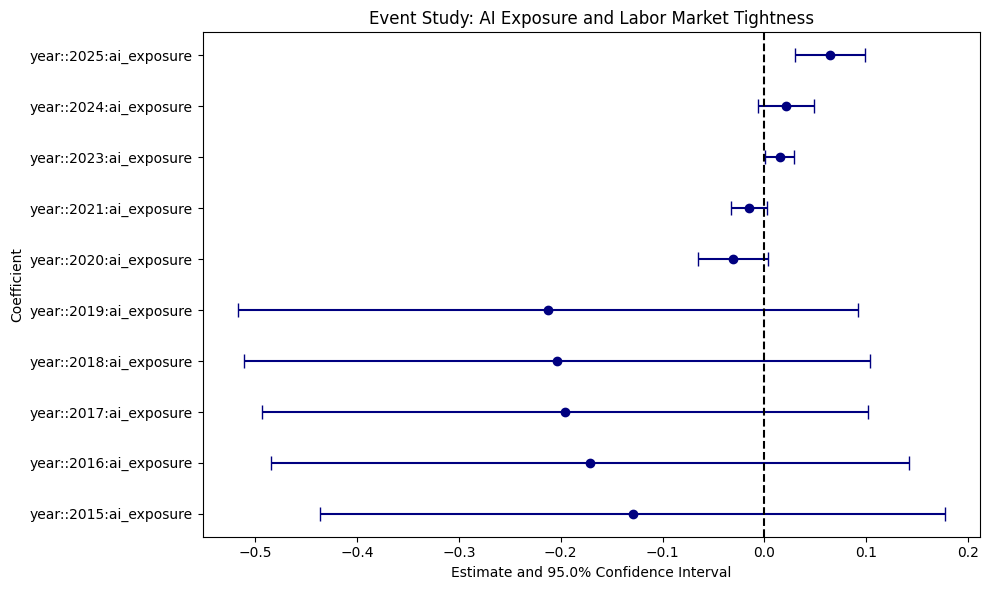

In [69]:
# ============================================================
# MODEL 5: EVENT STUDY — LOG RELATION
# Reference year = 2022
# ============================================================

event_relation = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_relation.summary())

# Plot
event_relation.iplot(
    title="Event Study: AI Exposure and Labor Market Tightness"
)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |      0.061 |        0.030 |     2.058 |      0.042 |  0.002 |   0.121 |
| year::2016:ai_exposure |      0.059 |        0.028 |     2.078 |      0.040 |  0.003 |   0.114 |
| year::2017:ai_exposure |      0.031 |        0.027 |     1.171 |      0.244 | -0.022 |   0.085 |
| year::2018:ai_exposure |     -0.007 |        0.023 |    -0.316 |      0.752 | -0.053 |   0.038 |
| year::2019:ai_exposure |     -0.013 |        0.019 |    -0.694 |      0.489 | -0.051 |   0.025 |
| year::2020:ai_exposure |      0.008 |        0.013 |     0.653 |      0.515 | -0.017 |   0.034 |
| year::2021:ai_exposure |     -0.008 |        0.012 |    -0.643 |      0.521 

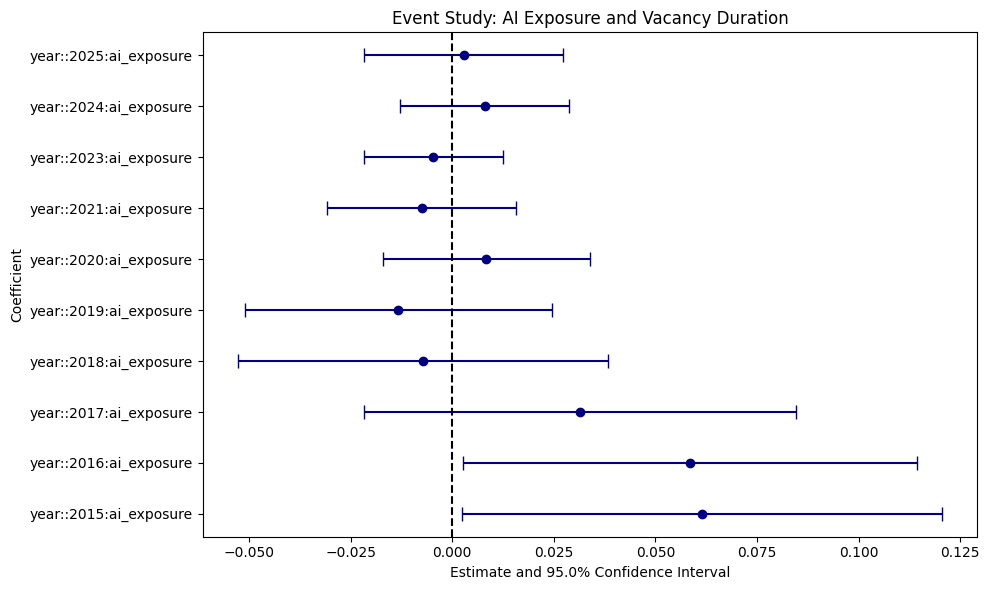

In [70]:
# ============================================================
# MODEL 6: EVENT STUDY — LOG VACANCIES
# Reference year = 2022
# ============================================================

event_vakanz = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_vakanz.summary())

# Plot
event_vakanz.iplot(

    title="Event Study: AI Exposure and Vacancy Duration",
)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |     -0.129 |        0.155 |    -0.837 |      0.404 | -0.436 |   0.177 |
| year::2016:ai_exposure |     -0.171 |        0.158 |    -1.081 |      0.282 | -0.484 |   0.142 |
| year::2017:ai_exposure |     -0.196 |        0.150 |    -1.306 |      0.194 | -0.493 |   0.101 |
| year::2018:ai_exposure |     -0.204 |        0.155 |    -1.314 |      0.191 | -0.511 |   0.103 |
| year::2019:ai_exposure |     -0.213 |        0.154 |    -1.383 |      0.169 | -0.517 |   0.092 |
| year::2020:ai_exposure |     -0.031 |        0.017 |    -1.796 |      0.075 | -0.065 |   0.003 |
| year::2021:ai_exposure |     -0.015 |        0.009 |    -1.664 |      0.09

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |      0.061 |        0.030 |     2.058 |      0.042 |  0.002 |   0.121 |
| year::2016:ai_exposure |      0.059 |        0.028 |     2.078 |      0.040 |  0.003 |   0.114 |
| year::2017:ai_exposure |      0.031 |        0.027 |     1.171 |      0.244 | -0.022 |   0.085 |
| year::2018:ai_exposure |     -0.007 |        0.023 |    -0.316 |      0.752 | -0.053 |   0.038 |
| year::2019:ai_exposure |     -0.013 |        0.019 |    -0.694 |      0.489 | -0.051 |   0.025 |
| year::2020:ai_exposure |      0.008 |        0.013 |     0.653 |      0.515 | -0.017 |   0.034 |
| year::2021:ai_exposure |     -0.008 |        0.012 |    -0.643 |      0.521 

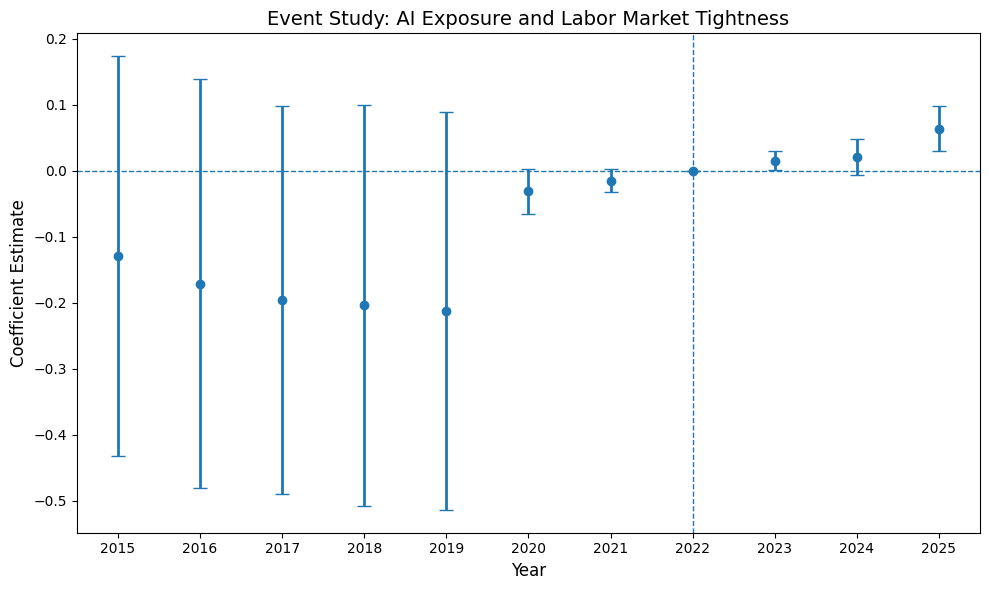

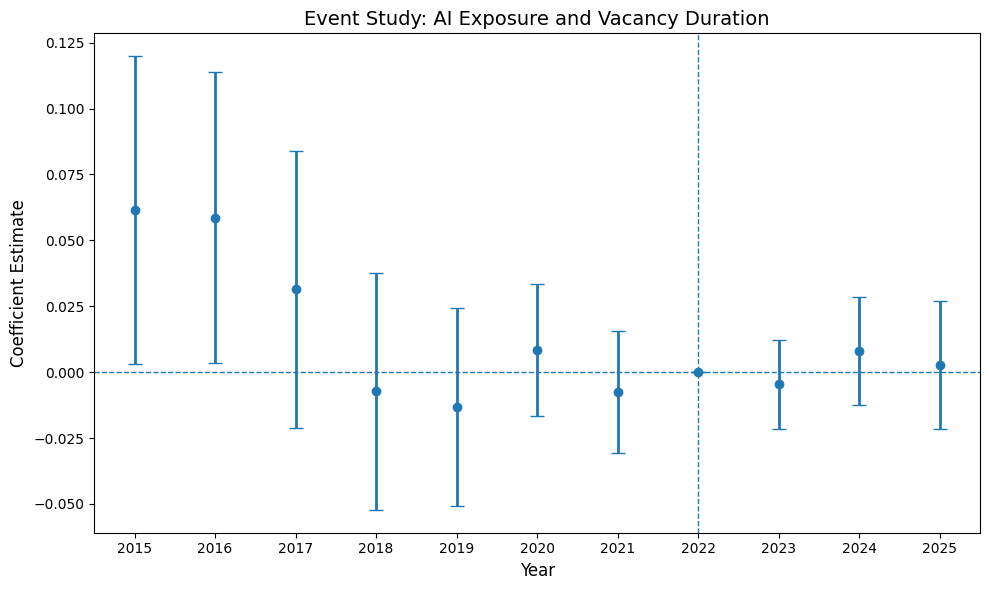


Event Study Results: Log Relation
    year  Estimate  Std. Error    ci_low   ci_high  percent_effect
0   2015 -0.129427    0.154657 -0.432555  0.173702      -12.140119
1   2016 -0.171026    0.158165 -0.481030  0.138978      -15.720035
2   2017 -0.195742    0.149919 -0.489583  0.098099      -17.777553
3   2018 -0.203652    0.154949 -0.507352  0.100049      -18.425368
4   2019 -0.212534    0.153640 -0.513669  0.088600      -19.146736
5   2020 -0.031039    0.017278 -0.064904  0.002827       -3.056183
6   2021 -0.014908    0.008961 -0.032472  0.002656       -1.479726
10  2022  0.000000    0.000000  0.000000  0.000000        0.000000
7   2023  0.014819    0.007334  0.000444  0.029193        1.492894
8   2024  0.021429    0.013856 -0.005729  0.048586        2.166000
9   2025  0.063929    0.017361  0.029902  0.097956        6.601667

Event Study Results: Log Vakanz
    year  Estimate  Std. Error    ci_low   ci_high  percent_effect
0   2015  0.061430    0.029846  0.002931  0.119929        6.3

In [71]:
# ============================================================
# FULL EVENT STUDY CODE:
# 1. Estimate event-study models
# 2. Extract coefficients
# 3. Plot professional figures
# ============================================================

import numpy as np
import pandas as pd
import pyfixest as pf
import matplotlib.pyplot as plt

# Make sure year is numeric
df["year"] = df["year"].astype(int)

# ============================================================
# MODEL 5: EVENT STUDY — LOG RELATION
# ============================================================

event_relation = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_relation.summary())


# ============================================================
# MODEL 6: EVENT STUDY — LOG VAKANZ
# ============================================================

event_vakanz = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_vakanz.summary())


# ============================================================
# FUNCTION TO PREPARE EVENT-STUDY COEFFICIENTS
# ============================================================

def prepare_event_df(model):
    event_df = model.tidy().reset_index()

    event_df = event_df[
        event_df["Coefficient"].str.contains("ai_exposure")
    ].copy()

    event_df["year"] = (
        event_df["Coefficient"]
        .str.extract(r"(\d{4})")
        .astype(int)
    )

    event_df["ci_low"] = (
        event_df["Estimate"] - 1.96 * event_df["Std. Error"]
    )

    event_df["ci_high"] = (
        event_df["Estimate"] + 1.96 * event_df["Std. Error"]
    )

    # Add omitted reference year = 2022
    ref_row = pd.DataFrame({
        "Coefficient": ["2022 reference year"],
        "Estimate": [0],
        "Std. Error": [0],
        "year": [2022],
        "ci_low": [0],
        "ci_high": [0]
    })

    event_df = pd.concat([event_df, ref_row], ignore_index=True)
    event_df = event_df.sort_values("year")

    event_df["percent_effect"] = (
        np.exp(event_df["Estimate"]) - 1
    ) * 100

    return event_df


# Prepare both event-study datasets
relation_df = prepare_event_df(event_relation)
vakanz_df = prepare_event_df(event_vakanz)


# ============================================================
# FIGURE 1: AI EXPOSURE AND LABOR MARKET TIGHTNESS
# ============================================================

plt.figure(figsize=(10, 6))

plt.errorbar(
    relation_df["year"],
    relation_df["Estimate"],
    yerr=[
        relation_df["Estimate"] - relation_df["ci_low"],
        relation_df["ci_high"] - relation_df["Estimate"]
    ],
    fmt="o",
    capsize=5,
    linewidth=2
)

plt.axhline(y=0, linestyle="--", linewidth=1)
plt.axvline(x=2022, linestyle="--", linewidth=1)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Coefficient Estimate", fontsize=12)

plt.title(
    "Event Study: AI Exposure and Labor Market Tightness",
    fontsize=14
)

plt.xticks(relation_df["year"])
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2: AI EXPOSURE AND VACANCY DURATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.errorbar(
    vakanz_df["year"],
    vakanz_df["Estimate"],
    yerr=[
        vakanz_df["Estimate"] - vakanz_df["ci_low"],
        vakanz_df["ci_high"] - vakanz_df["Estimate"]
    ],
    fmt="o",
    capsize=5,
    linewidth=2
)

plt.axhline(y=0, linestyle="--", linewidth=1)
plt.axvline(x=2022, linestyle="--", linewidth=1)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Coefficient Estimate", fontsize=12)

plt.title(
    "Event Study: AI Exposure and Vacancy Duration",
    fontsize=14
)

plt.xticks(vakanz_df["year"])
plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL: PRINT CLEAN EVENT-STUDY TABLES
# ============================================================

print("\nEvent Study Results: Log Relation")
print(
    relation_df[
        ["year", "Estimate", "Std. Error", "ci_low", "ci_high", "percent_effect"]
    ]
)

print("\nEvent Study Results: Log Vakanz")
print(
    vakanz_df[
        ["year", "Estimate", "Std. Error", "ci_low", "ci_high", "percent_effect"]
    ]
)

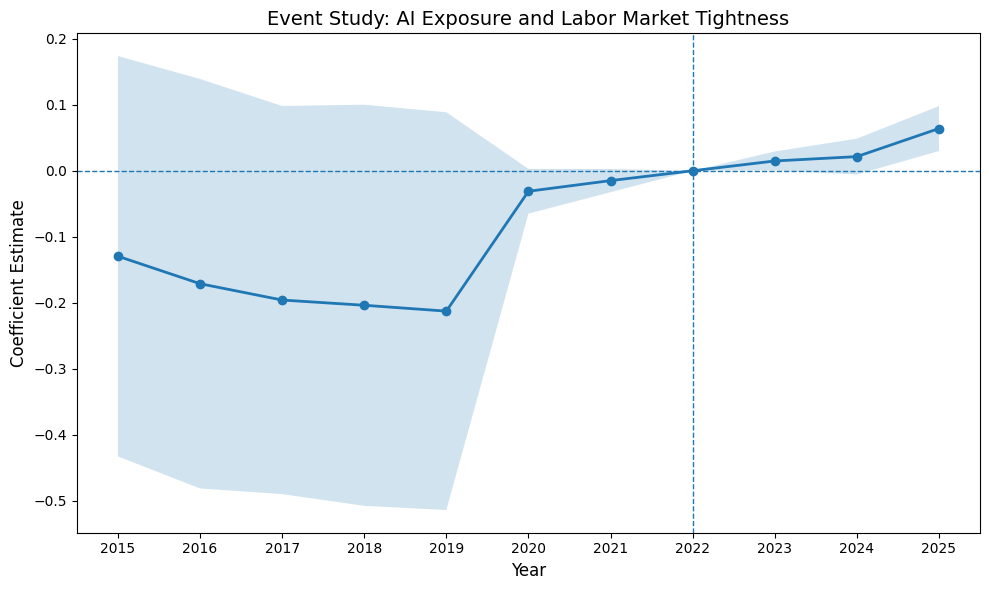

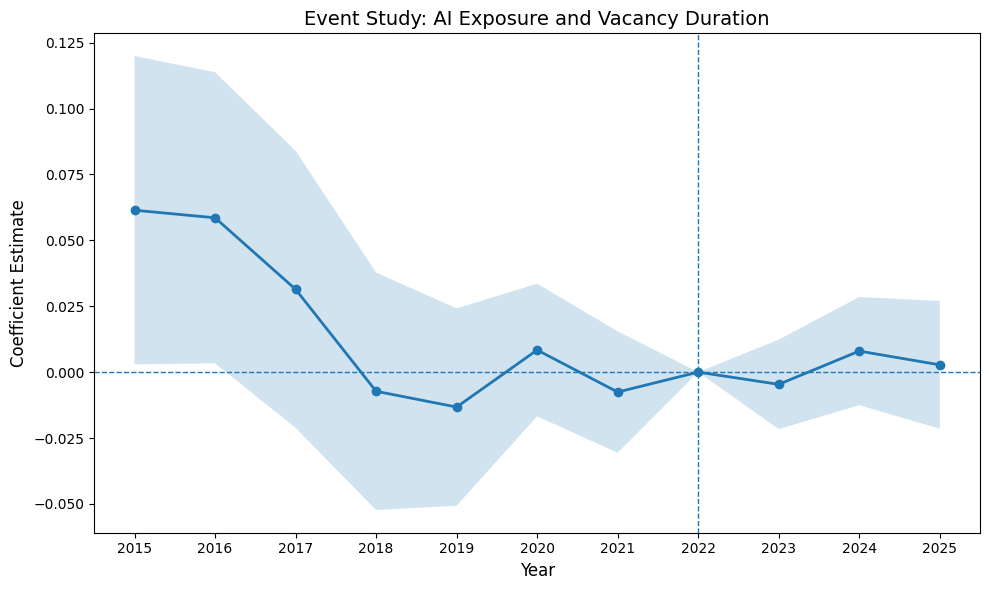

In [72]:
# ============================================================
# PROFESSIONAL EVENT STUDY PLOTS
# (Journal / Thesis Style)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def prepare_event_df(model):

    df_event = model.tidy().reset_index()

    # Keep AI interaction terms only
    df_event = df_event[
        df_event["Coefficient"].str.contains("ai_exposure")
    ].copy()

    # Extract year
    df_event["year"] = (
        df_event["Coefficient"]
        .str.extract(r"(\d{4})")
        .astype(int)
    )

    # Confidence intervals
    df_event["ci_low"] = (
        df_event["Estimate"]
        - 1.96 * df_event["Std. Error"]
    )

    df_event["ci_high"] = (
        df_event["Estimate"]
        + 1.96 * df_event["Std. Error"]
    )

    # Add omitted reference year
    ref_row = pd.DataFrame({
        "Coefficient": ["Reference"],
        "Estimate": [0],
        "Std. Error": [0],
        "year": [2022],
        "ci_low": [0],
        "ci_high": [0]
    })

    df_event = pd.concat(
        [df_event, ref_row],
        ignore_index=True
    )

    df_event = df_event.sort_values("year")

    return df_event


# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

relation_df = prepare_event_df(event_relation)
vakanz_df = prepare_event_df(event_vakanz)


# ============================================================
# FIGURE 1:
# EVENT STUDY — LABOR MARKET TIGHTNESS
# ============================================================

plt.figure(figsize=(10,6))

# Line connecting coefficients
plt.plot(
    relation_df["year"],
    relation_df["Estimate"],
    marker='o',
    linewidth=2
)

# Confidence intervals
plt.fill_between(
    relation_df["year"],
    relation_df["ci_low"],
    relation_df["ci_high"],
    alpha=0.2
)

# Horizontal zero line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

# Vertical treatment line
plt.axvline(
    x=2022,
    linestyle='--',
    linewidth=1
)

# Labels
plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Coefficient Estimate",
    fontsize=12
)

plt.title(
    "Event Study: AI Exposure and Labor Market Tightness",
    fontsize=14
)

# Improve layout
plt.xticks(relation_df["year"])

plt.tight_layout()

plt.show()


# ============================================================
# FIGURE 2:
# EVENT STUDY — VACANCY DURATION
# ============================================================

plt.figure(figsize=(10,6))

# Line connecting coefficients
plt.plot(
    vakanz_df["year"],
    vakanz_df["Estimate"],
    marker='o',
    linewidth=2
)

# Confidence intervals
plt.fill_between(
    vakanz_df["year"],
    vakanz_df["ci_low"],
    vakanz_df["ci_high"],
    alpha=0.2
)

# Horizontal zero line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

# Vertical treatment line
plt.axvline(
    x=2022,
    linestyle='--',
    linewidth=1
)

# Labels
plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Coefficient Estimate",
    fontsize=12
)

plt.title(
    "Event Study: AI Exposure and Vacancy Duration",
    fontsize=14
)

# Improve layout
plt.xticks(vakanz_df["year"])

plt.tight_layout()

plt.show()

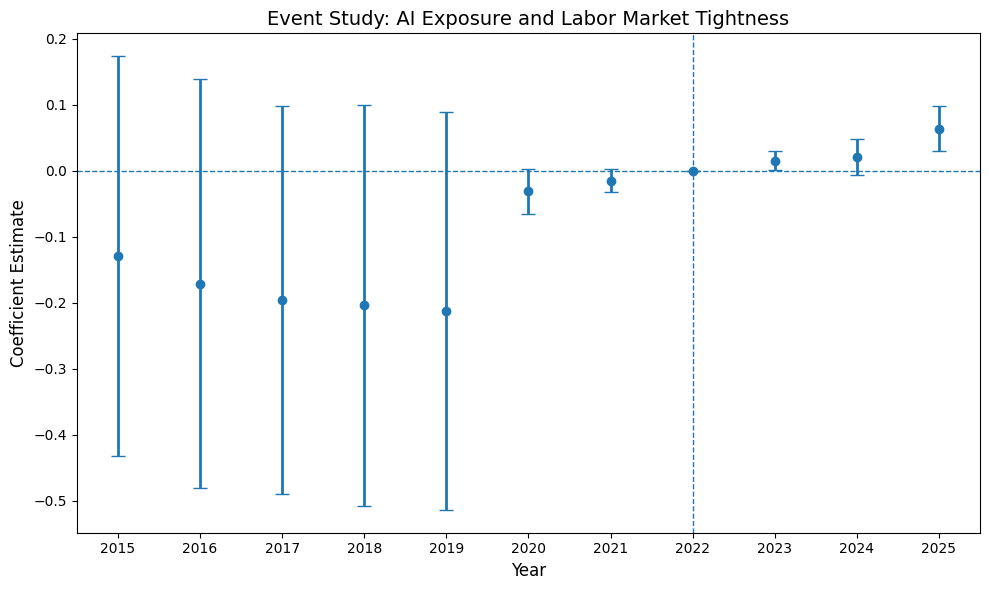

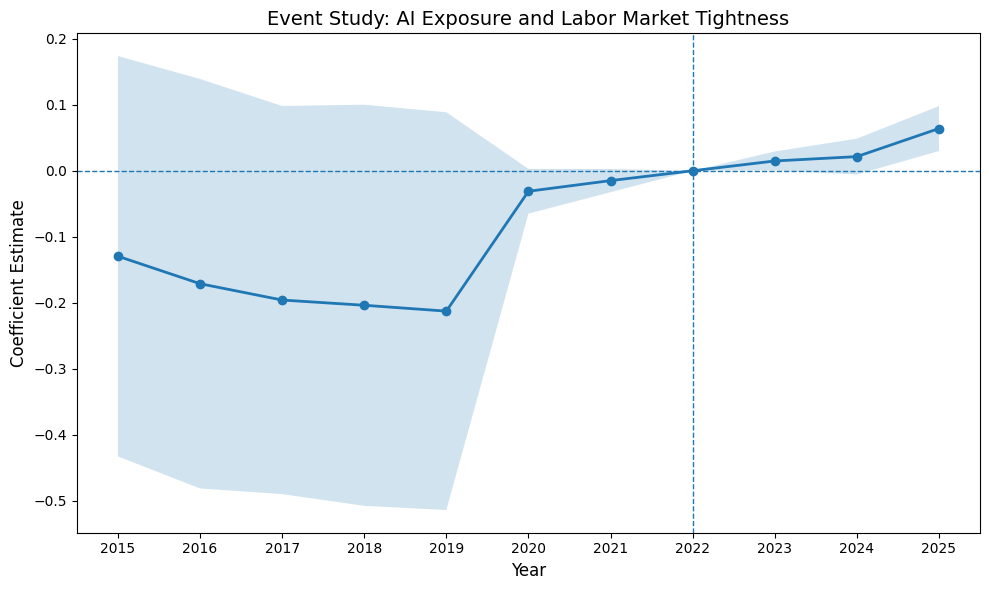

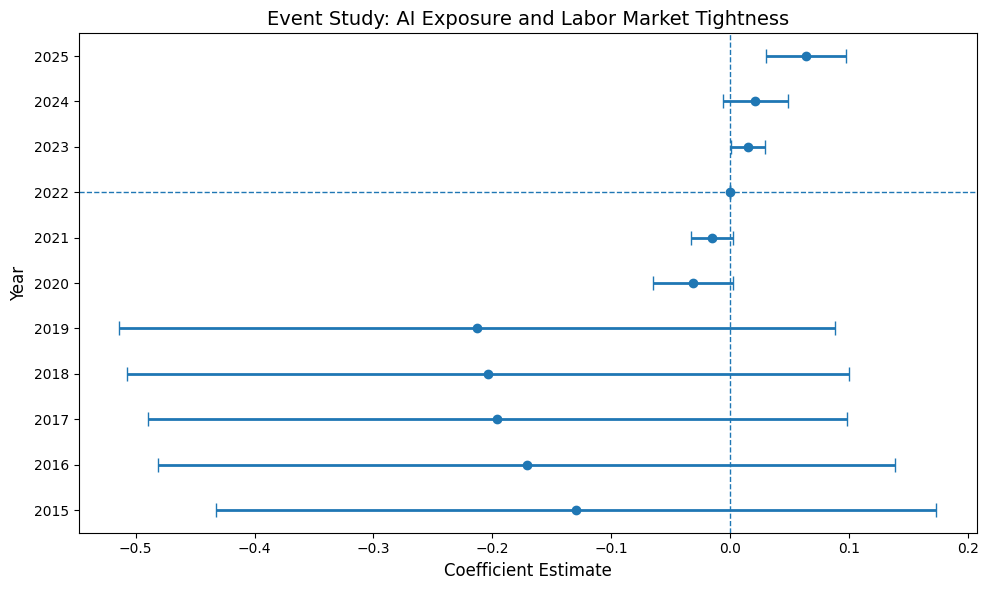

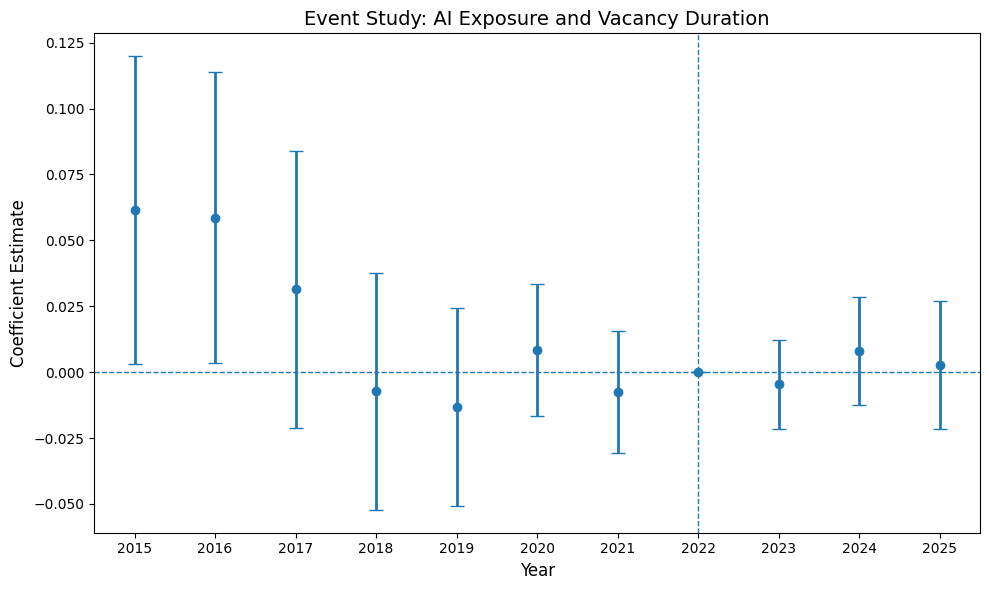

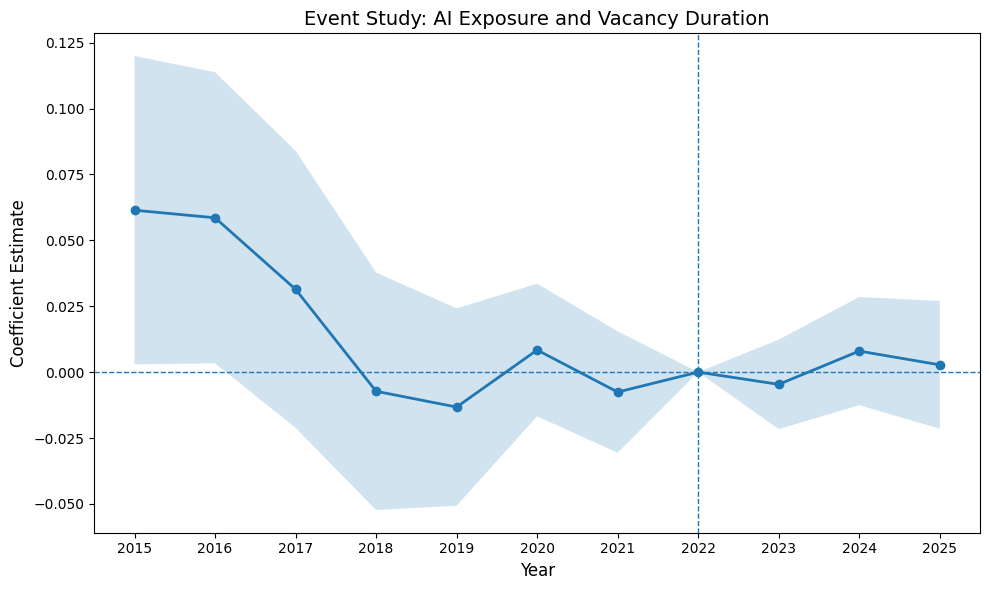

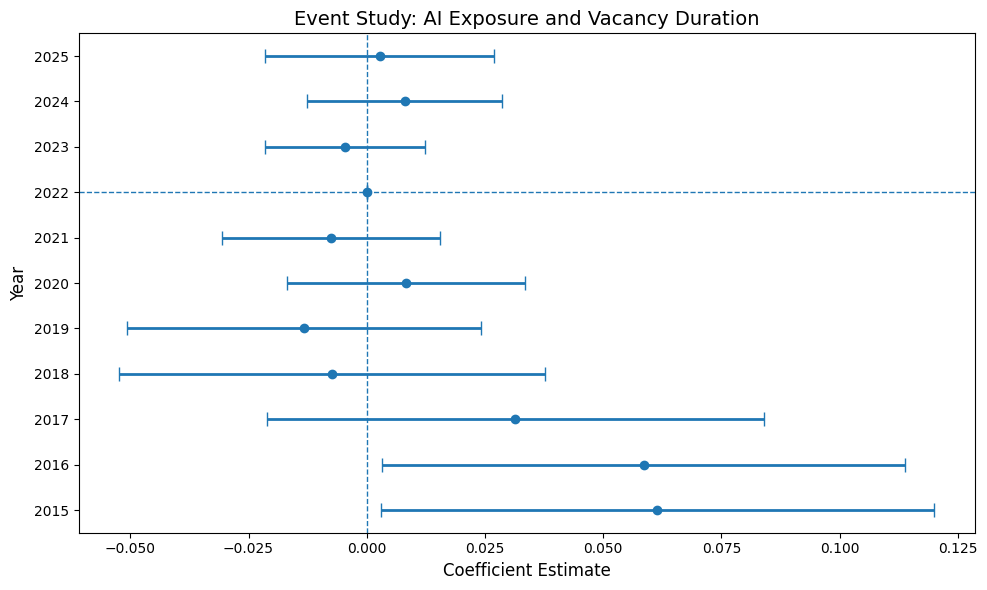

In [73]:
# ============================================================
# CREATE MULTIPLE EVENT-STUDY FIGURES
# 6 PLOTS TOTAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare event-study dataframe
# ------------------------------------------------------------

def prepare_event_df(model):
    event_df = model.tidy().reset_index()

    event_df = event_df[
        event_df["Coefficient"].str.contains("ai_exposure")
    ].copy()

    event_df["year"] = (
        event_df["Coefficient"]
        .str.extract(r"(\d{4})")
        .astype(int)
    )

    event_df["ci_low"] = event_df["Estimate"] - 1.96 * event_df["Std. Error"]
    event_df["ci_high"] = event_df["Estimate"] + 1.96 * event_df["Std. Error"]

    ref_row = pd.DataFrame({
        "Coefficient": ["Reference"],
        "Estimate": [0],
        "Std. Error": [0],
        "year": [2022],
        "ci_low": [0],
        "ci_high": [0]
    })

    event_df = pd.concat([event_df, ref_row], ignore_index=True)
    event_df = event_df.sort_values("year")

    return event_df


relation_df = prepare_event_df(event_relation)
vakanz_df = prepare_event_df(event_vakanz)


# ------------------------------------------------------------
# Function 1: vertical error-bar plot
# ------------------------------------------------------------

def plot_errorbar(df_plot, title, filename):
    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_plot["year"],
        df_plot["Estimate"],
        yerr=[
            df_plot["Estimate"] - df_plot["ci_low"],
            df_plot["ci_high"] - df_plot["Estimate"]
        ],
        fmt="o",
        capsize=5,
        linewidth=2
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(2022, linestyle="--", linewidth=1)

    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Coefficient Estimate", fontsize=12)
    plt.title(title, fontsize=14)

    plt.xticks(df_plot["year"])
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# Function 2: line plot with shaded confidence intervals
# ------------------------------------------------------------

def plot_line_shaded(df_plot, title, filename):
    plt.figure(figsize=(10, 6))

    plt.plot(
        df_plot["year"],
        df_plot["Estimate"],
        marker="o",
        linewidth=2
    )

    plt.fill_between(
        df_plot["year"],
        df_plot["ci_low"],
        df_plot["ci_high"],
        alpha=0.2
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(2022, linestyle="--", linewidth=1)

    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Coefficient Estimate", fontsize=12)
    plt.title(title, fontsize=14)

    plt.xticks(df_plot["year"])
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# Function 3: horizontal coefficient plot
# ------------------------------------------------------------

def plot_horizontal(df_plot, title, filename):
    plt.figure(figsize=(10, 6))

    plt.errorbar(
        df_plot["Estimate"],
        df_plot["year"],
        xerr=[
            df_plot["Estimate"] - df_plot["ci_low"],
            df_plot["ci_high"] - df_plot["Estimate"]
        ],
        fmt="o",
        capsize=5,
        linewidth=2
    )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.axhline(2022, linestyle="--", linewidth=1)

    plt.xlabel("Coefficient Estimate", fontsize=12)
    plt.ylabel("Year", fontsize=12)
    plt.title(title, fontsize=14)

    plt.yticks(df_plot["year"])
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# CREATE 3 FIGURES FOR EVENT STUDY 1: LOG RELATION
# ============================================================

plot_errorbar(
    relation_df,
    "Event Study: AI Exposure and Labor Market Tightness",
    "event_relation_errorbar.png"
)

plot_line_shaded(
    relation_df,
    "Event Study: AI Exposure and Labor Market Tightness",
    "event_relation_shaded_ci.png"
)

plot_horizontal(
    relation_df,
    "Event Study: AI Exposure and Labor Market Tightness",
    "event_relation_horizontal.png"
)


# ============================================================
# CREATE 3 FIGURES FOR EVENT STUDY 2: LOG VAKANZ
# ============================================================

plot_errorbar(
    vakanz_df,
    "Event Study: AI Exposure and Vacancy Duration",
    "event_vakanz_errorbar.png"
)

plot_line_shaded(
    vakanz_df,
    "Event Study: AI Exposure and Vacancy Duration",
    "event_vakanz_shaded_ci.png"
)

plot_horizontal(
    vakanz_df,
    "Event Study: AI Exposure and Vacancy Duration",
    "event_vakanz_horizontal.png"
)

In [74]:
import numpy as np
import pandas as pd
import pyfixest as pf

# Rename column to remove spaces/capital issues
df = df.rename(columns={
    "log_Median wage": "log_median_wage",
    "log_Median": "log_median_wage",
    "Median wage": "median_wage"
})

# If you already have log_median_wage but it is text, convert it to numeric
df["log_median_wage"] = pd.to_numeric(df["log_median_wage"], errors="coerce")

# Also make sure log_bestand is numeric
df["log_bestand"] = pd.to_numeric(df["log_bestand"], errors="coerce")

# Drop missing values only for controlled models
df_controls = df.dropna(subset=[
    "log_relation",
    "log_vakanz",
    "ai_exposure",
    "post",
    "log_bestand",
    "log_median_wage",
    "kldb3",
    "year"
]).copy()

In [75]:
did_relation_controls = pf.feols(
    "log_relation ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(did_relation_controls.summary())


did_vakanz_controls = pf.feols(
    "log_vakanz ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz_controls.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |     -0.109 |        0.091 |    -1.196 |      0.234 | -0.288 |   0.071 |
| log_median_wage  |      4.633 |        1.841 |     2.517 |      0.013 |  0.987 |   8.279 |
| ai_exposure:post |      0.216 |        0.091 |     2.368 |      0.020 |  0.035 |   0.396 |
---
RMSE: 0.7 R2: 0.846 R2 Within: 0.041 
None
###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |      0.016 |       

In [76]:
df_nocovid = df_controls[
    ~df_controls["year"].isin([2020, 2021])
].copy()

In [77]:
event_relation_controls = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)
print(event_relation_controls.summary())
event_vakanz_controls = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)
print(event_vakanz_controls.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |     -0.181 |        0.149 |    -1.213 |      0.228 | -0.476 |   0.114 |
| year::2016:ai_exposure |     -0.228 |        0.154 |    -1.483 |      0.141 | -0.532 |   0.077 |
| year::2017:ai_exposure |     -0.250 |        0.146 |    -1.712 |      0.090 | -0.539 |   0.039 |
| year::2018:ai_exposure |     -0.243 |        0.152 |    -1.596 |      0.113 | -0.545 |   0.059 |
| year::2019:ai_exposure |     -0.261 |        0.153 |    -1.706 |      0.091 | -0.565 |   0.042 |
| year::2020:ai_exposure |     -0.080 |        0.031 |    -2.611 |      0.010 | -0.140 |  -0.019 |
| year::2021:ai_exposure |     -0.051 |        0.020 |    -2.563 |      0.01

In [78]:
df_nocovid = df_controls[
    ~df_controls["year"].isin([2020, 2021])
].copy()

In [79]:
did_relation_controls = pf.feols(
    "log_relation ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(did_relation_controls.summary())


did_vakanz_controls = pf.feols(
    "log_vakanz ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz_controls.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |     -0.109 |        0.091 |    -1.196 |      0.234 | -0.288 |   0.071 |
| log_median_wage  |      4.633 |        1.841 |     2.517 |      0.013 |  0.987 |   8.279 |
| ai_exposure:post |      0.216 |        0.091 |     2.368 |      0.020 |  0.035 |   0.396 |
---
RMSE: 0.7 R2: 0.846 R2 Within: 0.041 
None
###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |      0.016 |       

high_ai
0    670
1    582
Name: count, dtype: int64


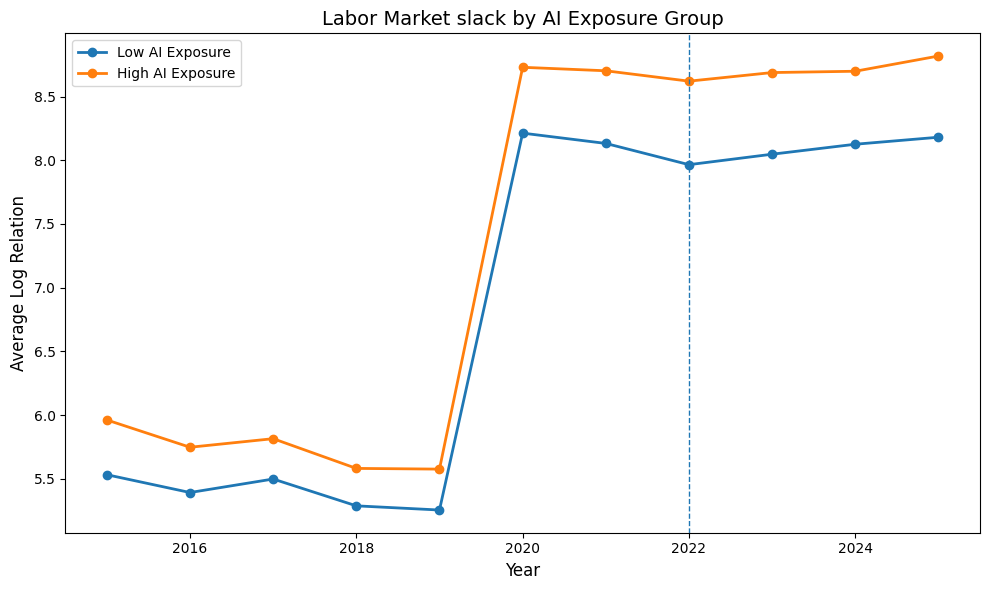

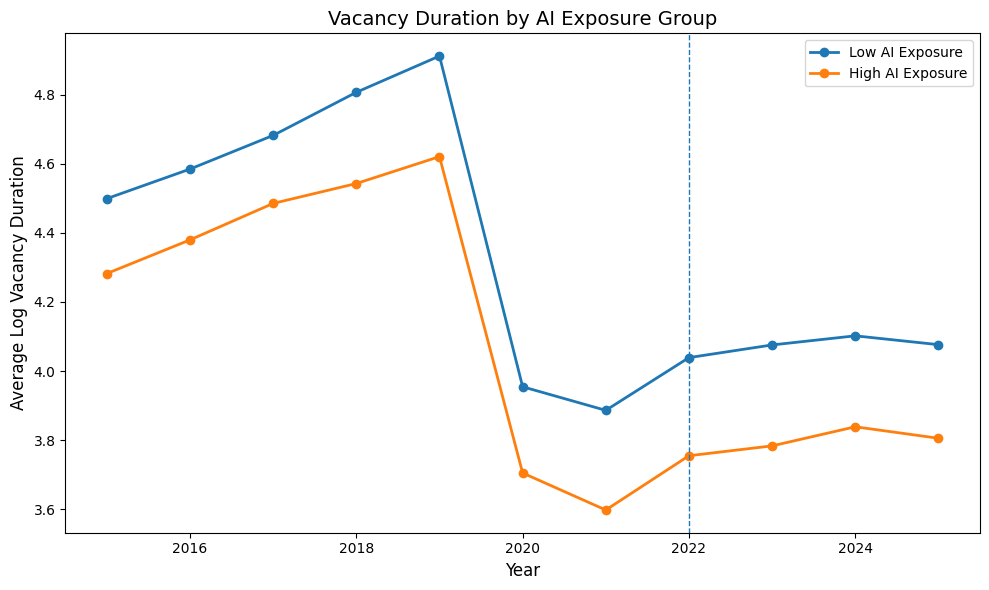

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\models\feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['post'].
            
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\models\feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['post'].
            
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\models\feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['post'].
            
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  582

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand     |     -0.122 |        0.125 |    -0.981 |      0.331 | -0.372 |   0.128 |
| log_median_wage |      5.232 |        2.285 |     2.290 |      0.026 |  0.650 |   9.815 |
---
RMSE: 0.724 R2: 0.836 R2 Within: 0.03 
None
###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  670

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand     |     -0.111 |        0.140 |    -0.791 |      0.432 | -0.391 |   0.169 |
| log_median_wage |      4.742 |        2.603 

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\models\feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['post'].
            
  warnings.warn(


In [80]:
# ============================================================
# HETEROGENEITY ANALYSIS:
# HIGH AI vs LOW AI OCCUPATIONS
# ============================================================

import numpy as np
import pandas as pd
import pyfixest as pf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CREATE HIGH-AI GROUP
# ------------------------------------------------------------

# Median AI exposure
median_ai = df_controls["ai_exposure"].median()

# High AI occupation = 1 if above median
df_controls["high_ai"] = (
    df_controls["ai_exposure"] > median_ai
).astype(int)

print(df_controls["high_ai"].value_counts())


# ============================================================
# 2. DESCRIPTIVE TRENDS:
# LABOR MARKET TIGHTNESS
# ============================================================

relation_trend = (
    df_controls
    .groupby(["year", "high_ai"])["log_relation"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for group in [0, 1]:

    temp = relation_trend[
        relation_trend["high_ai"] == group
    ]

    label_name = (
        "Low AI Exposure"
        if group == 0
        else "High AI Exposure"
    )

    plt.plot(
        temp["year"],
        temp["log_relation"],
        marker="o",
        linewidth=2,
        label=label_name
    )

plt.axvline(
    x=2022,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Log Relation", fontsize=12)

plt.title(
    "Labor Market slack by AI Exposure Group",
    fontsize=14
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 3. DESCRIPTIVE TRENDS:
# VACANCY DURATION
# ============================================================

vakanz_trend = (
    df_controls
    .groupby(["year", "high_ai"])["log_vakanz"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for group in [0, 1]:

    temp = vakanz_trend[
        vakanz_trend["high_ai"] == group
    ]

    label_name = (
        "Low AI Exposure"
        if group == 0
        else "High AI Exposure"
    )

    plt.plot(
        temp["year"],
        temp["log_vakanz"],
        marker="o",
        linewidth=2,
        label=label_name
    )

plt.axvline(
    x=2022,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Log Vacancy Duration", fontsize=12)

plt.title(
    "Vacancy Duration by AI Exposure Group",
    fontsize=14
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4. HETEROGENEITY DID:
# HIGH AI OCCUPATIONS ONLY
# ============================================================

high_ai_df = df_controls[
    df_controls["high_ai"] == 1
].copy()

low_ai_df = df_controls[
    df_controls["high_ai"] == 0
].copy()


# ------------------------------------------------------------
# HIGH AI — LOG RELATION
# ------------------------------------------------------------

did_relation_high = pf.feols(
    "log_relation ~ post + log_bestand + log_median_wage | kldb3 + year",
    data=high_ai_df,
    vcov={"CRV1": "kldb3"}
)

print(did_relation_high.summary())


# ------------------------------------------------------------
# LOW AI — LOG RELATION
# ------------------------------------------------------------

did_relation_low = pf.feols(
    "log_relation ~ post + log_bestand + log_median_wage | kldb3 + year",
    data=low_ai_df,
    vcov={"CRV1": "kldb3"}
)

print(did_relation_low.summary())


# ------------------------------------------------------------
# HIGH AI — LOG VAKANZ
# ------------------------------------------------------------

did_vakanz_high = pf.feols(
    "log_vakanz ~ post + log_bestand + log_median_wage | kldb3 + year",
    data=high_ai_df,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz_high.summary())


# ------------------------------------------------------------
# LOW AI — LOG VAKANZ
# ------------------------------------------------------------

did_vakanz_low = pf.feols(
    "log_vakanz ~ post + log_bestand + log_median_wage | kldb3 + year",
    data=low_ai_df,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz_low.summary())

In [81]:
hetero_relation = pf.feols(
    "log_relation ~ high_ai:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(hetero_relation.summary())
hetero_vakanz = pf.feols(
    "log_vakanz ~ high_ai:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(hetero_vakanz.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand     |     -0.104 |        0.091 |    -1.150 |      0.252 | -0.284 |   0.075 |
| log_median_wage |      4.717 |        1.864 |     2.530 |      0.013 |  1.024 |   8.410 |
| high_ai:post    |      0.287 |        0.154 |     1.863 |      0.065 | -0.018 |   0.593 |
---
RMSE: 0.702 R2: 0.845 R2 Within: 0.036 
None
###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand     |      0.016 |        0.017

In [82]:
# ============================================================
# ROBUSTNESS CHECK: EXCLUDING COVID YEARS 2020–2021
# ============================================================

import numpy as np
import pandas as pd
import pyfixest as pf

# ------------------------------------------------------------
# 1. Create no-COVID sample
# ------------------------------------------------------------

df_nocovid = df_controls[
    ~df_controls["year"].isin([2020, 2021])
].copy()

print("Original observations:", len(df_controls))
print("No-COVID observations:", len(df_nocovid))


# ============================================================
# 2. CONTINUOUS DID — LOG RELATION
# ============================================================

did_relation_nocovid = pf.feols(
    "log_relation ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(did_relation_nocovid.summary())


# ============================================================
# 3. CONTINUOUS DID — LOG VAKANZ
# ============================================================

did_vakanz_nocovid = pf.feols(
    "log_vakanz ~ ai_exposure:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz_nocovid.summary())


# ============================================================
# 4. EVENT STUDY — LOG RELATION, NO COVID YEARS
# Reference year = 2022
# ============================================================

event_relation_nocovid = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(event_relation_nocovid.summary())


# ============================================================
# 5. EVENT STUDY — LOG VAKANZ, NO COVID YEARS
# Reference year = 2022
# ============================================================

event_vakanz_nocovid = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(event_vakanz_nocovid.summary())


# ============================================================
# 6. BINARY HIGH-AI ROBUSTNESS, NO COVID YEARS
# ============================================================

hetero_relation_nocovid = pf.feols(
    "log_relation ~ high_ai:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(hetero_relation_nocovid.summary())


hetero_vakanz_nocovid = pf.feols(
    "log_vakanz ~ high_ai:post + log_bestand + log_median_wage | kldb3 + year",
    data=df_nocovid,
    vcov={"CRV1": "kldb3"}
)

print(hetero_vakanz_nocovid.summary())

Original observations: 1252
No-COVID observations: 1026
###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1026

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |     -0.134 |        0.089 |    -1.501 |      0.136 | -0.311 |   0.043 |
| log_median_wage  |      5.160 |        1.975 |     2.612 |      0.010 |  1.247 |   9.072 |
| ai_exposure:post |      0.259 |        0.121 |     2.131 |      0.035 |  0.018 |   0.499 |
---
RMSE: 0.695 R2: 0.842 R2 Within: 0.061 
None
###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1026

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|--

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |     -0.181 |        0.149 |    -1.213 |      0.228 | -0.476 |   0.114 |
| year::2016:ai_exposure |     -0.228 |        0.154 |    -1.483 |      0.141 | -0.532 |   0.077 |
| year::2017:ai_exposure |     -0.250 |        0.146 |    -1.712 |      0.090 | -0.539 |   0.039 |
| year::2018:ai_exposure |     -0.243 |        0.152 |    -1.596 |      0.113 | -0.545 |   0.059 |
| year::2019:ai_exposure |     -0.261 |        0.153 |    -1.706 |      0.091 | -0.565 |   0.042 |
| year::2020:ai_exposure |     -0.080 |        0.031 |    -2.611 |      0.010 | -0.140 |  -0.019 |
| year::2021:ai_exposure |     -0.051 |        0.020 |    -2.563 |      0.01

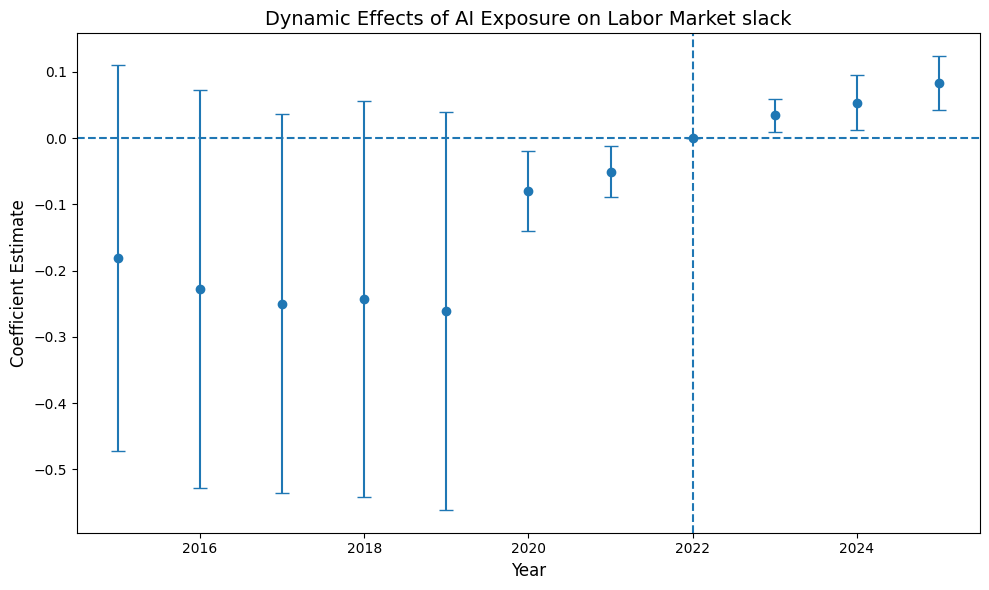

###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |      0.060 |        0.030 |     2.006 |      0.047 |  0.001 |   0.118 |
| year::2016:ai_exposure |      0.055 |        0.029 |     1.931 |      0.056 | -0.001 |   0.112 |
| year::2017:ai_exposure |      0.029 |        0.027 |     1.058 |      0.292 | -0.025 |   0.082 |
| year::2018:ai_exposure |     -0.010 |        0.023 |    -0.422 |      0.674 | -0.055 |   0.036 |
| year::2019:ai_exposure |     -0.014 |        0.019 |    -0.702 |      0.484 | -0.052 |   0.025 |
| year::2020:ai_exposure |      0.002 |        0.014 |     0.163 |      0.871 | -0.025 |   0.030 |
| year::2021:ai_exposure |     -0.012 |        0.012 |    -0.977 |      0.331 

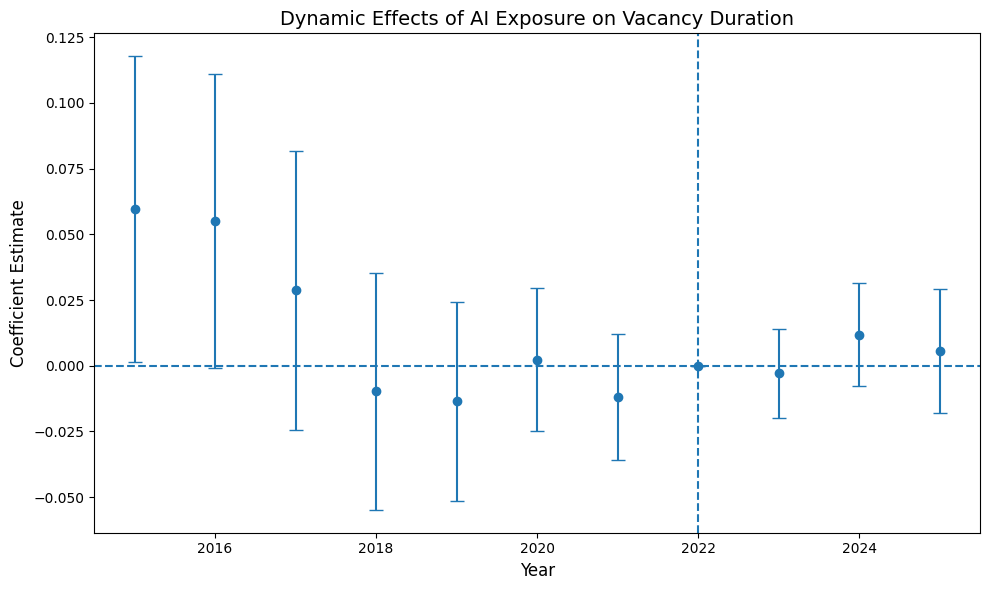

In [83]:
# ============================================================
# EVENT STUDY FIGURES WITH CONTROLS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyfixest as pf

# ============================================================
# 1. EVENT STUDY: LOG RELATION
# ============================================================

event_relation_controls = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(event_relation_controls.summary())


# ------------------------------------------------------------
# Extract coefficients
# ------------------------------------------------------------

coef_rel = event_relation_controls.coef()
se_rel = event_relation_controls.se()

years_rel = []
estimates_rel = []
ses_rel = []

for name in coef_rel.index:

    if "year::" in name:

        year = int(name.split("::")[1].split(":")[0])

        years_rel.append(year)
        estimates_rel.append(coef_rel[name])
        ses_rel.append(se_rel[name])

# Add reference year 2022
years_rel.append(2022)
estimates_rel.append(0)
ses_rel.append(0)

# Create dataframe
plot_rel = pd.DataFrame({
    "year": years_rel,
    "estimate": estimates_rel,
    "se": ses_rel
})

plot_rel = plot_rel.sort_values("year")

# Confidence intervals
plot_rel["ci_low"] = (
    plot_rel["estimate"] - 1.96 * plot_rel["se"]
)

plot_rel["ci_high"] = (
    plot_rel["estimate"] + 1.96 * plot_rel["se"]
)

# ------------------------------------------------------------
# Plot Figure 3
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.errorbar(
    plot_rel["year"],
    plot_rel["estimate"],
    yerr=1.96 * plot_rel["se"],
    fmt='o',
    capsize=5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.axvline(
    x=2022,
    linestyle='--'
)

plt.xlabel("Year", fontsize=12)

plt.ylabel(
    "Coefficient Estimate",
    fontsize=12
)

plt.title(
    "Dynamic Effects of AI Exposure on Labor Market slack",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. EVENT STUDY: LOG VAKANZ
# ============================================================

event_vakanz_controls = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) + log_bestand + log_median_wage | kldb3 + year",
    data=df_controls,
    vcov={"CRV1": "kldb3"}
)

print(event_vakanz_controls.summary())


# ------------------------------------------------------------
# Extract coefficients
# ------------------------------------------------------------

coef_vak = event_vakanz_controls.coef()
se_vak = event_vakanz_controls.se()

years_vak = []
estimates_vak = []
ses_vak = []

for name in coef_vak.index:

    if "year::" in name:

        year = int(name.split("::")[1].split(":")[0])

        years_vak.append(year)
        estimates_vak.append(coef_vak[name])
        ses_vak.append(se_vak[name])

# Add reference year
years_vak.append(2022)
estimates_vak.append(0)
ses_vak.append(0)

# Create dataframe
plot_vak = pd.DataFrame({
    "year": years_vak,
    "estimate": estimates_vak,
    "se": ses_vak
})

plot_vak = plot_vak.sort_values("year")

# Confidence intervals
plot_vak["ci_low"] = (
    plot_vak["estimate"] - 1.96 * plot_vak["se"]
)

plot_vak["ci_high"] = (
    plot_vak["estimate"] + 1.96 * plot_vak["se"]
)

# ------------------------------------------------------------
# Plot Figure 4
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.errorbar(
    plot_vak["year"],
    plot_vak["estimate"],
    yerr=1.96 * plot_vak["se"],
    fmt='o',
    capsize=5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.axvline(
    x=2022,
    linestyle='--'
)

plt.xlabel("Year", fontsize=12)

plt.ylabel(
    "Coefficient Estimate",
    fontsize=12
)

plt.title(
    "Dynamic Effects of AI Exposure on Vacancy Duration",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [84]:
df_post = df[df["year"] >= 2023].copy()

In [86]:
fit_post_relation = pf.feols(
    "log_relation ~ ai_exposure | year",
    data=df_post,
    vcov={"CRV1":"kldb3"}
)

fit_post_vakanz = pf.feols(
    "log_vakanz ~ ai_exposure | year",
    data=df_post,
    vcov={"CRV1":"kldb3"}
)
print(fit_post_relation.summary())
print(fit_post_vakanz.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  346

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |      0.413 |        0.137 |     3.002 |      0.003 |  0.140 |   0.685 |
---
RMSE: 1.234 R2: 0.074 R2 Within: 0.073 
None
###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  346

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |     -0.162 |        0.031 |    -5.226 |      0.000 | -0.223 |  -0.100 |
---
RMSE: 0.288 R2: 0.182 R2 Within: 0.18 
None


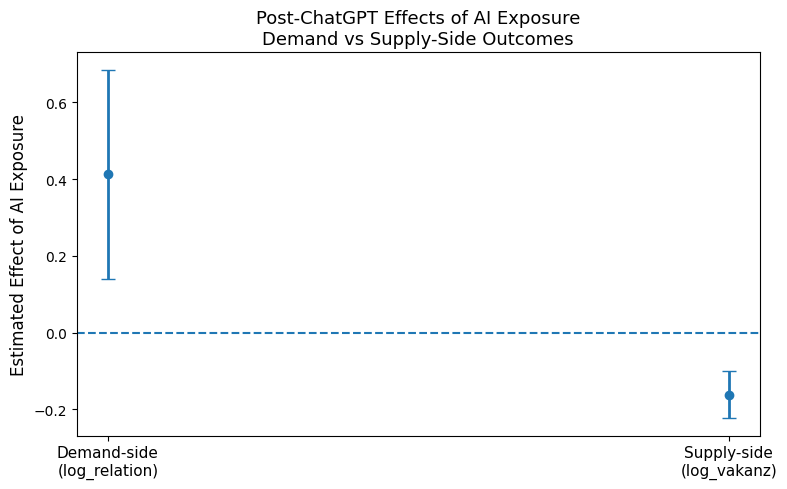

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Coefficients and confidence intervals
# -----------------------------
variables = ["Demand-side\n(log_relation)",
             "Supply-side\n(log_vakanz)"]

coef = [0.413, -0.162]

lower = [0.140, -0.223]
upper = [0.685, -0.100]

# calculate error bars
errors = [
    np.array(coef) - np.array(lower),
    np.array(upper) - np.array(coef)
]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(variables))

ax.errorbar(
    x,
    coef,
    yerr=errors,
    fmt='o',
    capsize=5,
    linewidth=2
)

ax.axhline(0, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(variables, fontsize=11)

ax.set_ylabel("Estimated Effect of AI Exposure", fontsize=12)
ax.set_title("Post-ChatGPT Effects of AI Exposure\nDemand vs Supply-Side Outcomes", fontsize=13)

plt.tight_layout()
plt.show()

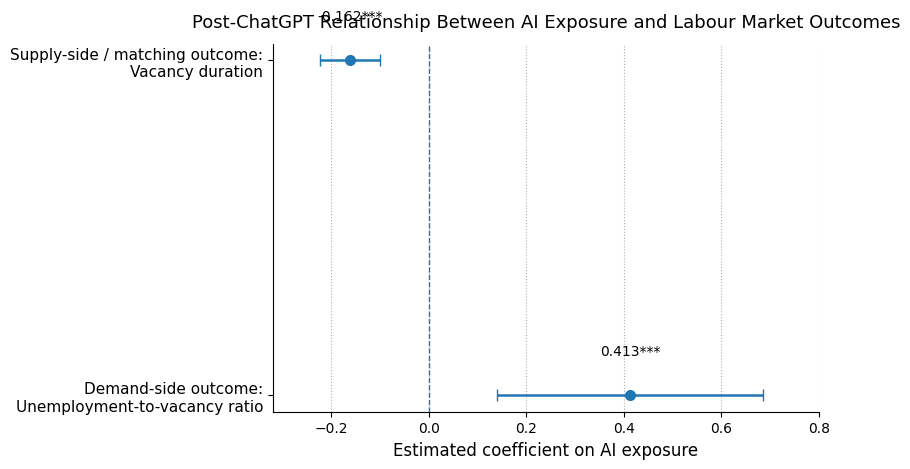

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Post-ChatGPT robustness results
# -----------------------------
outcomes = [
    "Demand-side outcome:\nUnemployment-to-vacancy ratio",
    "Supply-side / matching outcome:\nVacancy duration"
]

coef = np.array([0.413, -0.162])
lower = np.array([0.140, -0.223])
upper = np.array([0.685, -0.100])

xerr = np.vstack([coef - lower, upper - coef])
y_pos = np.arange(len(outcomes))

# -----------------------------
# Journal-style coefficient plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.errorbar(
    coef,
    y_pos,
    xerr=xerr,
    fmt='o',
    markersize=7,
    capsize=4,
    linewidth=1.8,
    elinewidth=1.8
)

ax.axvline(0, linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes, fontsize=11)

ax.set_xlabel("Estimated coefficient on AI exposure", fontsize=12)
ax.set_title(
    "Post-ChatGPT Relationship Between AI Exposure and Labour Market Outcomes",
    fontsize=13,
    pad=12
)

ax.text(
    0.413, 0.12,
    "0.413***",
    ha="center",
    fontsize=10
)

ax.text(
    -0.162, 1.12,
    "-0.162***",
    ha="center",
    fontsize=10
)

ax.set_xlim(-0.32, 0.80)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

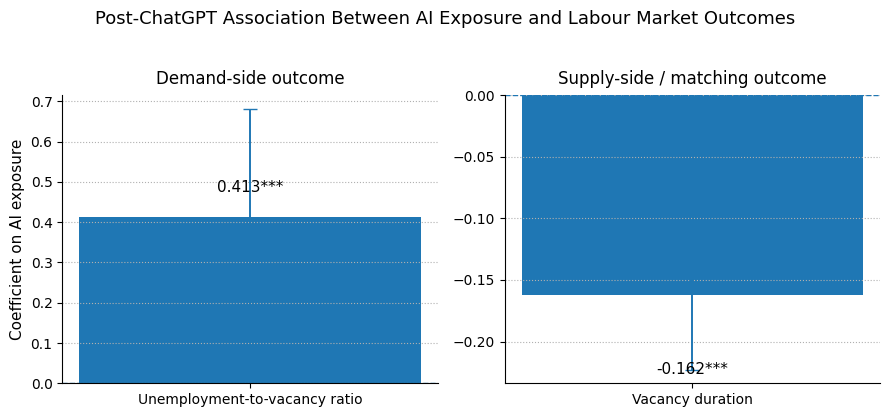

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Results
labels = ["Demand-side\nlog_relation", "Supply-side / matching\nlog_vakanz"]
coef = np.array([0.413, -0.162])
se = np.array([0.137, 0.031])

ci_low = coef - 1.96 * se
ci_high = coef + 1.96 * se

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

titles = [
    "Demand-side outcome",
    "Supply-side / matching outcome"
]

subtitles = [
    "Unemployment-to-vacancy ratio",
    "Vacancy duration"
]

for i, ax in enumerate(axes):
    ax.bar([0], [coef[i]], width=0.45)
    ax.errorbar(
        [0],
        [coef[i]],
        yerr=[[coef[i] - ci_low[i]], [ci_high[i] - coef[i]]],
        fmt="none",
        capsize=5,
        linewidth=1.4
    )
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(titles[i], fontsize=12, pad=8)
    ax.text(
        0, coef[i] + (0.055 if coef[i] > 0 else -0.055),
        f"{coef[i]:.3f}***",
        ha="center",
        va="bottom" if coef[i] > 0 else "top",
        fontsize=11
    )

    ax.set_xticks([0])
    ax.set_xticklabels([subtitles[i]], fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", linewidth=0.8)

axes[0].set_ylabel("Coefficient on AI exposure", fontsize=11)

fig.suptitle(
    "Post-ChatGPT Association Between AI Exposure and Labour Market Outcomes",
    fontsize=13,
    y=1.03
)

plt.tight_layout()
plt.show()